# XGBoost2GPU Example

Este notebook demonstra como usar a classe `XGBoost2GPU` para gerar código CUDA a partir de modelos XGBoost treinados com TreeLUT.

## Importações e Configuração do Ambiente

In [108]:
import sys
import os
from pathlib import Path



# Importações principais
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Minhas importações
from LoadDataset import LoadDataset
from treelut import TreeLUTClassifier
from xgboost2gpu import XGBoost2GPU


## Parâmetros do Modelo

In [109]:
# Parâmetros para o XGBoost
xgb_params = {
    'objective': 'multi:softmax', 
    'num_class': 2, 
    'n_estimators':7, 
    'max_depth': 7, 
    'eta': 0.8
}

# Parâmetros para o TreeLUT
treelut_params = {
    'w_feature': 3, 
    'w_tree': 3,
    'bits_features': 16,
    'pipeline': [0, 0, 0], 
    'dir_path': './results/OutputFiles/MakeDataset/',
    'style': 'mux',
    'argmax': True,
    'quantized': True
}

# Parâmetros para o make_classification
make_classification_params = {
    'n_samples': 100000, 
    'n_features': 30, 
    'n_informative': 10, 
    'n_redundant': 0, 
    'n_classes': xgb_params['num_class'], 
    'random_state': 42
}

# Parâmetros para o XGBoost2GPU
xgb2gpu_params = {
    'percentage_to_cut': 0.30,
    'strategy': 'flat',
    'level_importance': 2,
    'progress_importance': 0,
    'level_bias': -1,
    'max_cut_percentage': 0.3,
    'urgency_override_threshold': 1.5,
    'output_file': './results/prune.csv'
}

## Carregamento e Preparação dos Dados

Vamos usar um dataset sintético para demonstração. Em um cenário real, você pode usar qualquer dataset de classificação.

In [110]:
# Gerar dados sintéticos para demonstração
from sklearn.datasets import make_classification

# Criar dataset sintético
X, y = make_classification(**make_classification_params)


# # Load Sus dataset
# susy = pd.read_csv('../data/SUSY_int.csv')
# data = susy.drop(columns=['target'])
# target = susy['target'].astype('int')

# Load Covtype dataset
# data, target = LoadDataset.load_covtype()

# Converter para DataFrame para facilitar manipulação
data = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
target = pd.Series(y, name='target')





print(f"Dataset shape: {data.shape}")
print(f"Classes: {np.unique(target)}")
print(f"Class distribution: {np.bincount(target)}")


Dataset shape: (100000, 30)
Classes: [0 1]
Class distribution: [50003 49997]


In [111]:

# Converter para uint8 para compatibilidade
data_un = data.astype('int32')
data_un = data_un.astype(f'uint{treelut_params["bits_features"]}')


X_train, X_test, y_train, y_test = train_test_split(
    data_un, target, test_size=0.2, random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Obter valores máximos e mínimos para quantização
max_values = X_test.max().astype(f'uint{treelut_params["bits_features"]}').to_numpy()
min_values = X_test.min().astype(f'uint{treelut_params["bits_features"]}').to_numpy()

print("Valores máximos por feature:")
print(max_values)
print("\nValores mínimos por feature:")
print(min_values)

Valores máximos por feature:
[65535 65535 65535 65535 65535 65535 65535 65535 65535 65535 65535 65535
 65535 65535 65535 65535 65535 65535 65535 65535 65535 65535 65535 65535
 65535 65535 65535 65535 65535 65535]

Valores mínimos por feature:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## Quantização dos Dados

In [112]:
# Aplicar normalização Min-Max
scaler = MinMaxScaler()
w_feature_treelut = treelut_params['w_feature']

X_train_min_max = np.round(scaler.fit_transform(X_train) * (2**w_feature_treelut - 1))
X_test_min_max = np.clip(
    np.round(scaler.transform(X_test) * (2**w_feature_treelut - 1)), 
    0, 2**w_feature_treelut - 1
)
X_valid_min_max = np.clip(
    np.round(scaler.transform(X_valid) * (2**w_feature_treelut - 1)), 
    0, 2**w_feature_treelut - 1
)

# Quantização simples usando operação bit-wise
X_train_quantized = np.array(X_train, dtype=np.int32) & (2**w_feature_treelut - 1)
X_test_quantized = np.array(X_test, dtype=np.int32) & (2**w_feature_treelut - 1)
X_valid_quantized = np.array(X_valid, dtype=np.int32) & (2**w_feature_treelut - 1)

print(f"Dados originais shape: {X_train.shape}")
print(f"Dados quantizados shape: {X_train_quantized.shape}")

Dados originais shape: (64000, 30)
Dados quantizados shape: (64000, 30)


## Treinamento do Modelo XGBoost

In [113]:
# Treinar modelo XGBoost com dados quantizados
xgb_clf = XGBClassifier(**xgb_params)
xgb_clf.fit(X_train_quantized, y_train)
y_pred_xgb = xgb_clf.predict(X_test_quantized)
print(f"Acurácia XGBoost (dados quantizados): {accuracy_score(y_pred_xgb, y_test):.3f}")

# Treinar modelo XGBoost com dados originais para comparação
xgb_clf_original = XGBClassifier(**xgb_params)
xgb_clf_original.fit(X_train, y_train)
y_pred_xgb_original = xgb_clf_original.predict(X_test)
print(f"Acurácia XGBoost (dados originais): {accuracy_score(y_pred_xgb_original, y_test):.3f}")

# Treinar modelo XGBoost com dados min-max normalizados
xgb_clf_min_max = XGBClassifier(**xgb_params)
xgb_clf_min_max.fit(X_train_min_max, y_train)
y_pred_xgb_min_max = xgb_clf_min_max.predict(X_test_min_max)
print(f"Acurácia XGBoost (min-max): {accuracy_score(y_pred_xgb_min_max, y_test):.3f}")

Acurácia XGBoost (dados quantizados): 0.906
Acurácia XGBoost (dados originais): 0.953
Acurácia XGBoost (min-max): 0.877


## Conversão para TreeLUT

In [114]:
# Escolher dados de teste baseado nos parâmetros do TreeLUT
treelut_X_test = X_test if treelut_params['quantized'] else X_test_quantized

# Criar e converter modelo TreeLUT
treelut_clf = TreeLUTClassifier(
    xgb_model=xgb_clf_min_max, 
    **treelut_params, 
    min=min_values, 
    max=max_values
)

treelut_clf.convert()
y_pred_treelut = treelut_clf.predict(X_test_min_max)
print(f"Acurácia TreeLUT: {accuracy_score(y_pred_treelut, y_test):.3f}")

# Save verilog
treelut_clf.verilog()
treelut_clf.testbench(treelut_X_test, y_test)

# Mostrar informações sobre as árvores
print(f"\nNúmero de árvores: {len(treelut_clf.trees)}")
print(f"Número total de nós: {sum(treelut_clf.nodes())}")
print(f"Número de nós por árvore: {treelut_clf.nodes()}")
print(f"Número de classes: {treelut_clf.n_classes}")

Acurácia TreeLUT: 0.877

Número de árvores: 14
Número total de nós: 3238
Número de nós por árvore: [199, 199, 209, 209, 231, 231, 243, 243, 245, 245, 251, 251, 241, 241]
Número de classes: 2


## Geração de Código CUDA com XGBoost2GPU

In [115]:
# Criar instância do XGBoost2GPU
xgb2gpu = XGBoost2GPU(treelut_model=treelut_clf, 
                      w_feature=treelut_params['w_feature'],
                      w_tree=treelut_params['w_tree'], 
                      n_samples=X_valid.shape[0],
                      n_threads=256,
                      n_blocks=780,
                      debug=False)

# Create results directory if it doesn't exist
results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

# Definir arquivo de saída
output_file = f"./results/xgboost_cuda_generated.cu"

# Gerar código CUDA
xgb2gpu.generate_cuda_code(output_file, optimization=True)
print(f"✅ Código CUDA gerado com sucesso em: {output_file}")

# Calcular e salvar probabilidades de corte
xgb2gpu.calculate_forest_probabilities(**xgb2gpu_params)
print("✅ Probabilidades de corte calculadas e salvas em: ./results/prune.csv")


CUDA code generated and saved to ./results/xgboost_cuda_generated.cu
✅ Código CUDA gerado com sucesso em: ./results/xgboost_cuda_generated.cu
✅ Probabilidades de corte calculadas e salvas em: ./results/prune.csv


### Análise de Probabilidades de Corte

In [116]:
prune_matrix = xgb2gpu.prune_matrix(save_matrix=True)
unique_rows, counts = np.unique(prune_matrix, axis=0, return_counts=True)

print(f"Total de amostras: {len(prune_matrix)}")
print(f"Padrões únicos: {len(unique_rows)}")
print(f"Padrões que se repetem: {len(counts[counts > 1])}")
print(f"Maior repetição: {max(counts)}")

# Valor de 0 e 1 de cada linha
print("Valores de 0 e 1 de cada linha:")
num_1s = []
num_0s = []
for row in prune_matrix:
    num_1s.append(np.sum(row))
    num_0s.append(len(row) - np.sum(row))
print(f"Número médio de 1s: {np.mean(num_1s):.3f}")
print(f"Número médio de 0s: {np.mean(num_0s):.3f}")

Total de amostras: 199680
Padrões únicos: 199680
Padrões que se repetem: 0
Maior repetição: 1
Valores de 0 e 1 de cada linha:


/tmp/ipykernel_222835/4065114643.py:15: RuntimeWarning: overflow encountered in scalar subtract
  num_0s.append(len(row) - np.sum(row))


Número médio de 1s: 29965128028.923
Número médio de 0s: 18446651662213609472.000


In [117]:
# Salvar X_test em um arquivo CSV
def save_test_data_to_csv(X_test, file_path):
    try:
        # Drop header and index to match the expected format
        if isinstance(X_test, pd.DataFrame):
            X_test = X_test.values  # Convert DataFrame to numpy array if needed
            # Drop header
        elif isinstance(X_test, pd.Series):
            X_test = X_test.values.reshape(-1, 1)  # Convert Series to 2D array
        elif not isinstance(X_test, np.ndarray):
            raise ValueError("X_test deve ser um DataFrame ou um numpy array.")
        # Save to CSV
        df = pd.DataFrame(X_test)
        df.to_csv(file_path, index=False, header=False)
        print(f"✅ Dados de teste salvos em: {file_path}")
    except Exception as e:
        print(f"❌ Erro ao salvar os dados de teste: {e}")
save_test_data_to_csv(X_valid_min_max, "./results/input.csv")
save_test_data_to_csv(y_valid, "./results/expected_output.csv")

✅ Dados de teste salvos em: ./results/input.csv
✅ Dados de teste salvos em: ./results/expected_output.csv


## Próximos Passos

Para usar o código CUDA gerado:

1. **Compilação**: Compile o arquivo `.cu` usando `nvcc`
2. **Dados de entrada**: Prepare arquivos CSV com os dados de teste:
   - `input.csv`: Dados de entrada para inferência
   - `expected_output.csv`: Rótulos esperados para validação
   - `prune.csv`: Vetor de poda para controlar quais nós usar
3. **Execução**: Execute o programa CUDA compilado
4. **Análise**: Verifique a acurácia e performance

### Exemplo de compilação:
```bash
nvcc -o xgboost_gpu xgboost_cuda_generated.cu
./xgboost_gpu
```

### Visualização de Importâncias

In [118]:
import collections


def consequence_cut(tree, cut_nodes:list):
    """
    Determines the consequence of cutting nodes in a tree.
    Returns a set of nodes that are affected by the cuts.
    """
    affected_nodes = set()
    
    for node_id in cut_nodes:
        # Verifica se o nó a ser cortado é um nó de decisão.
        if node_id in tree and tree[node_id].get('type') == 'split':
            # Inicia uma fila para a travessia a partir dos filhos diretos.
            queue = []
            left_child = tree[node_id].get('no')
            right_child = tree[node_id].get('yes')

            if left_child is not None:
                queue.append(left_child)
            if right_child is not None:
                queue.append(right_child)
            
            # Realiza uma travessia (BFS) para encontrar todos os descendentes.
            while queue:
                current_node_id = queue.pop(0)
                if current_node_id not in affected_nodes:                
                    affected_nodes.add(current_node_id)
                    
                    current_node_data = tree.get(current_node_id)
                    
                    if current_node_data and current_node_data.get('type') == 'split':
                        grand_left_child = current_node_data.get('no')
                        grand_right_child = current_node_data.get('yes')
                        
                        if grand_left_child is not None:
                            queue.append(grand_left_child)
                        if grand_right_child is not None:
                            queue.append(grand_right_child)

    if not affected_nodes:
        print("No affected nodes found.")

    return affected_nodes


def node_id_complete_tree(tree):
    """
    Returns the tree dict updated with the "realID" key for each node.
    This key represents the node's ID based on its position in a complete tree.
        
    Args:
        tree (dict): The tree structure.
        max_nodes (int): The maximum number of nodes in the complete tree (optional, not used directly in the calculation).

    Returns:
        dict: The updated tree with "realID" for each node.
    """
    updated_tree = {node_id: data.copy() for node_id, data in tree.items()}
    
    # 1. Find the root node (the one without a 'parent_node' key)
    root_id = None
    for node_id, node_data in updated_tree.items():
        if 'parent_node' not in node_data:
            root_id = node_id
            break
            
    if root_id is None:
        raise ValueError("Root node not found in the tree.")

    # 2. Use a queue (deque) for Breadth-First Search (BFS)
    queue = collections.deque()
    
    # 3. Initialize the root's "realID" and add it to the queue
    updated_tree[root_id]['realID'] = 0
    queue.append(root_id)
    
    # 4. Process the queue until it is empty
    while queue:
        current_id = queue.popleft()
        current_node = updated_tree[current_id]
        
        # The parent's "realID" is needed to calculate the children's IDs
        parent_real_id = current_node['realID']
        
        # Process children only if the current node is a decision node ('split')
        if current_node.get('type') == 'split':
            # We assume 'no' is the left child and 'yes' is the right child
            left_child_id = current_node.get('no')
            right_child_id = current_node.get('yes')
            
            # Process the left child ('no')
            if left_child_id is not None and left_child_id in updated_tree:
                # Calculate the realID: 2 * p + 1
                updated_tree[left_child_id]['realID'] = 2 * parent_real_id + 2
                queue.append(left_child_id)

            # Process the right child ('yes')
            if right_child_id is not None and right_child_id in updated_tree:
                # Calculate the realID: 2 * p + 2
                updated_tree[right_child_id]['realID'] = 2 * parent_real_id + 1
                queue.append(right_child_id)
    
                
    return updated_tree
    

In [119]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import get_cmap

def save_trees_to_file(trees, filename='trees.txt'):
    with open(filename, 'w') as f:
        f.write(str(trees))
    print(f"Árvores salvas em {filename}")

def plot_tree_cut_distribution(trees, num_threads=1000, num_classes=3, num_trees_per_class=4):
    """
    Plota a distribuição de cortes dos nós para um conjunto de árvores,
    com as classes nas linhas e as árvores nas colunas.
    """
    if not trees:
        print("Nenhuma árvore para plotar.")
        return

    # Configuração do layout dos subplots (CLASSES x ÁRVORES)
    fig, axes = plt.subplots(
                            nrows=num_classes,
                            ncols=num_trees_per_class,
                            figsize=(20, 3 * num_classes),
                            squeeze=False,
                            constrained_layout=True)

    print(f"Plotando {num_trees_per_class} árvores por classe, para {num_classes} classes.")
    fig.suptitle(f'Distribuição de Cortes por Nó por Árvore (n_threads = {num_threads})', fontsize=16)

    # Paleta de cores por classe
    cmap = get_cmap('tab10')
    class_colors = [cmap(i) for i in range(num_classes)]

    # Loop principal para plotar cada árvore em sua posição correta na grade
    for class_idx in range(num_classes):
        for tree_idx in range(num_trees_per_class):
            # Calcula o índice da árvore na lista de dados
            # (Ex: Árvore 0 da Classe 1 -> 1 + 0*3 = índice 1)
            # (Ex: Árvore 1 da Classe 0 -> 0 + 1*3 = índice 3)
            list_key = class_idx + tree_idx * num_classes
            
            # Pega o subplot correspondente
            ax = axes[class_idx, tree_idx]

            # Verifica se a árvore existe nos dados carregados
            if list_key >= len(trees):
                ax.set_title(f'Classe {class_idx} - Árvore {tree_idx} (Ausente)')
                ax.axis('off')
                continue

            tree = trees[list_key]

            # Prepara dados para plotagem
            nodes = sorted(tree.keys())
            cut_counts = simulate_cuts(tree, num_threads)
            total_cuts_mean = sum(cut_counts.values()) / num_threads if num_threads > 0 else 0

            # Plotagem das barras
            ax.bar(nodes, [cut_counts.get(node, 0) for node in nodes],
                   color=class_colors[class_idx], alpha=0.7)

            # Customização do gráfico
            ax.set_title(f'Classe {class_idx} - Árvore {tree_idx} ({len(nodes)} nós)')
            ax.set_xlabel('ID do Nó')
            ax.set_ylabel('Contagem de Cortes')
            # if nodes:
            #     ax.set_xticks(nodes)
            #     ax.tick_params(axis='x', rotation=90, labelsize=8) # Rotaciona para melhor visualização
            #     ax.set_xlim(min(nodes) - 0.5, max(nodes) + 0.5)

            # Adiciona rótulo com a média de cortes
            total_cuts_label = f'Média de Cortes: {total_cuts_mean:.2f}'
            ax.text(0.5, 0.95, total_cuts_label, transform=ax.transAxes,
                    fontsize=10, ha='center', va='top', bbox=dict(facecolor='white', alpha=0.8))

            ax.set_ylim(0, max(cut_counts.values()) * 1.1 if cut_counts else 1)
            ax.set_facecolor('whitesmoke')
            ax.grid(axis='y', linestyle='--', alpha=0.6)

    plt.show()

def simulate_cuts(tree, num_threads):
    """
    Função de simulação para gerar contagens de cortes aleatórias para cada nó.
    """
    cut_counts = {node: 0 for node in tree.keys()}
    for thread in range(num_threads):
        for node, value in tree.items():
            # Gera um valor aleatório para simular a contagem de cortes
            cut_counts[node] += xgb2gpu.should_cut_node(thread,value['global_id'])

    return cut_counts



In [120]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def plot_cuts_per_thread(trees, num_threads=1000, num_classes=3):
    # Dicionário para armazenar cortes por thread
    thread_cuts = defaultdict(int)
    num_nodes = defaultdict(int)

    # Simulação: para cada thread, conta quantos nós foram cortados
    for thread_id in range(num_threads):
        if thread_id == 0: continue
        for tree in trees:
            for node, value in tree.items():
                if xgb2gpu.should_cut_node(thread_id, value['global_id']):
                    thread_cuts[thread_id] += 1
                num_nodes[thread_id] += 1
                
    mean_nodes = np.mean(list(num_nodes.values())) if num_nodes else 0

    # Prepara dados para plotagem
    cuts_count = [count for count in thread_cuts.values()]
    threads = range(num_threads)
    
    # Configuração do plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(threads, cuts_count, color='skyblue', edgecolor='navy', alpha=0.7)
    
    # Linha de média
    mean_cuts = np.mean(cuts_count)
    plt.axhline(mean_cuts, color='red', linestyle='--', 
                label=f'Média: {mean_cuts:.1f} cortes/thread')
    
    # Customização
    plt.title(f'Distribuição de Cortes por Thread (Total: {num_threads} threads, {mean_nodes:.1f} nodes)')
    plt.xlabel('ID da Thread')
    plt.ylabel('Número de Nós Cortados')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    
    # Ajusta eixos para melhor visualização
    max_cuts = max(cuts_count) if cuts_count else 0
    plt.ylim(0, max_cuts * 1.1)
    
    plt.tight_layout()
    plt.show()

trees_data = xgb2gpu.model.trees

# plot_cuts_per_thread(trees_data, num_threads=50, num_classes=xgb_params['num_class'])


In [121]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
try:
    from graphviz import Digraph
except ImportError:
    # Provides a clear message if the library is not installed.
    print("="*60)
    print("ERROR: The 'graphviz' library was not found.")
    print("Please install it with: pip install graphviz")
    print("Also, remember to install the Graphviz software on your system.")
    print("See instructions at: https://graphviz.org/download/")
    print("="*60)
    # Defines a fake 'Digraph' class to prevent the rest of the code from breaking immediately.
    class Digraph:
        def __init__(self, *args, **kwargs): pass
        def attr(self, *args, **kwargs): pass
        def node(self, *args, **kwargs): pass
        def edge(self, *args, **kwargs): pass
        def render(self, *args, **kwargs):
             print("Graphviz is not installed, cannot generate images.")

def simulate_multiple_cuts(tree, thread_id, cut_probability=0.2):
    """
    Simulates multiple cuts in a tree for a specific thread.
    Returns a set of nodes that were "cut".
    """
    cut_nodes = set()
    for node_id, value in tree.items():
        # Simulate the cut decision based on the thread ID and a cut probability.
        if xgb2gpu.should_cut_node(thread_id, value['global_id']):
            # If the node is cut, add it to the set of cut nodes.
            cut_nodes.add(node_id)

    return cut_nodes

def visualize_tree_traversal_path(
    trees, 
    thread_id_to_plot, 
    num_classes, 
    num_trees_per_class, 
    output_dir='individual_tree_visualizations',
    font_size=12
):
    """
    Generates a visual representation for each tree, showing the cut nodes
    and their direct children.

    Parameters:
        - trees: list of trees
        - thread_id_to_plot: int
        - num_classes: int
        - num_trees_per_class: int
        - output_dir: str
        - font_size: int (used in Graphviz labels and nodes)

    Node coloring:
        - Red: Cut node.
        - Yellow: Child of a cut node (priority over red).
        - Gray: Unaffected nodes.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Output directory created at: '{os.path.abspath(output_dir)}'")

    print(f"\n[Individual Visualization] Generating images for Thread ID: {thread_id_to_plot}...")
    
    generated_files = 0
    for class_idx in range(num_classes):
        for tree_idx in range(num_trees_per_class):
            list_key = class_idx + tree_idx * num_classes
            if list_key >= len(trees): continue

            tree = trees[list_key]
            if not tree: continue

            tree_nodes = set(tree.keys())
            cut_nodes = simulate_multiple_cuts(tree, thread_id_to_plot)
            yellow_nodes = consequence_cut(tree, cut_nodes)

            dot = Digraph(comment=f'Class {class_idx} - Tree {tree_idx} - Thread {thread_id_to_plot}')
            dot.attr('node', shape='circle', style='filled', fontname='helvetica', fontsize=str(font_size))
            dot.attr(label=f'Class {class_idx} | Tree {tree_idx}\nThread ID: {thread_id_to_plot}', fontsize=str(font_size))

            for node_id in sorted(tree_nodes):
                color = "#f0f0f0"
                if node_id in cut_nodes:
                    color = "#e57373"
                if node_id in yellow_nodes:
                    color = "#fff176"
                dot.node(str(node_id), label=str(node_id), fillcolor=color)

            for node_id, value in tree.items():
                left_child = value.get('no')
                right_child = value.get('yes')
                if left_child is not None:
                    dot.edge(str(node_id), str(left_child), color='black')
                if right_child is not None:
                    dot.edge(str(node_id), str(right_child), color='black')

            filename = f'class_{class_idx}_tree_{tree_idx}_thread_{thread_id_to_plot}'
            output_path = os.path.join(output_dir, filename)
            try:
                dot.render(output_path, format='png', view=False, cleanup=True)
                dot.render(output_path, format='svg', view=False, cleanup=True)
                generated_files += 1
            except Exception as e:
                print(f"\nERROR generating image with Graphviz: {e}")
                return

    if generated_files > 0:
        print(f"Done! {generated_files} image files saved in directory '{output_dir}'.")






trees_data = xgb2gpu.model.trees




In [122]:
def plot_forest_overview(trees, thread_id_to_plot, num_classes, num_trees_per_class,
                         output_file='forest_overview', font_size=10):
    """
    Generates a single grid image showing an overview of all trees in the forest,
    highlighting the nodes cut by a specific thread.

    Parameters:
        - trees: list of trees
        - thread_id_to_plot: int
        - num_classes: int
        - num_trees_per_class: int
        - output_file: str
        - font_size: int (controls all font sizes in the plot)
    """
    print(f"\n[Forest Overview] Generating grid for Thread ID: {thread_id_to_plot}...")

    fig, axes = plt.subplots(
        nrows=num_classes,
        ncols=num_trees_per_class,
        figsize=(num_trees_per_class * 2.5, num_classes * 0.8),
        squeeze=False,
        constrained_layout=True
    )
    fig.suptitle(f'Forest Overview - Cut Nodes (Thread ID: {thread_id_to_plot})', fontsize=font_size + 6)

    max_node_id = max(len(tree) for tree in trees if tree) if trees else 0

    cmap = ListedColormap(['#a0a0a0', "#f0f0f0", '#e57373', '#fff176'])

    num_cutted_nodes = 0

    for class_idx in range(num_classes):
        for tree_idx in range(num_trees_per_class):
            ax = axes[class_idx, tree_idx]
            ax.set_title(f'Class {class_idx} | Tree {tree_idx}', fontsize=font_size)
            ax.set_yticks([])

            list_key = class_idx + tree_idx * num_classes
            if list_key >= len(trees) or not trees[list_key]:
                ax.text(0.5, 0.5, 'Empty', ha='center', va='center',
                        fontsize=font_size - 1, color='gray')
                ax.set_xticks([])
                continue

            tree = node_id_complete_tree(trees[list_key])
            real_node_id = [dado['realID'] for dado in tree.values()]
            cut_nodes = simulate_multiple_cuts(trees[list_key], thread_id_to_plot)
            consequence_cuts = consequence_cut(trees[list_key], cut_nodes)

            status_bar = np.zeros((1, max_node_id))
            for node_id in range(max_node_id):
                if node_id in real_node_id:
                    status_bar[0, node_id] = 1
                if node_id in cut_nodes:
                    status_bar[0, node_id] = 2
                if node_id in consequence_cuts:
                    status_bar[0, node_id] = 3

            all_cutted_nodes = set(cut_nodes) | set(consequence_cuts)
            num_cutted_nodes += len(all_cutted_nodes)

            ax.imshow(status_bar, cmap=cmap, aspect='auto', interpolation='nearest', vmin=0, vmax=3)
            ax.set_xticks([])

    legend_patches = [
        plt.Rectangle((0, 0), 1, 1, color='#a0a0a0', label='Node Does Not Exist'),
        plt.Rectangle((0, 0), 1, 1, color='#e57373', label='Node Was Cut'),
        plt.Rectangle((0, 0), 1, 1, color='#fff176', label='Node Affected by Cut')
    ]
    fig.legend(handles=legend_patches, loc='center', ncol=3, bbox_to_anchor=(0.5, -0.20), fontsize=font_size)

    fig.text(0.5, -0.05, 'Node ID (Deeper levels to the right)',
             ha='center', va='center', fontsize=font_size + 2)

    plt.savefig(f'{output_file}.png', format='png', dpi=150, bbox_inches='tight')
    plt.savefig(f'{output_file}.svg', format='svg', bbox_inches='tight')

    print(f"Done! Forest overview saved to: '{os.path.abspath(output_file)}'")
    return num_cutted_nodes


### Aplicando Visualizações

In [130]:
thread_to_visualize = 113162

Output directory created at: '/home/olavo/Documentos/ufv/projects/XGBoost2GPU/misc/example/results/113162_individual_trees'

[Individual Visualization] Generating images for Thread ID: 113162...
Done! 14 image files saved in directory './results/113162_individual_trees'.

[Forest Overview] Generating grid for Thread ID: 113162...
Done! Forest overview saved to: '/home/olavo/Documentos/ufv/projects/XGBoost2GPU/misc/example/results/forest_overview'
Total nodes cut by thread 113162: 620


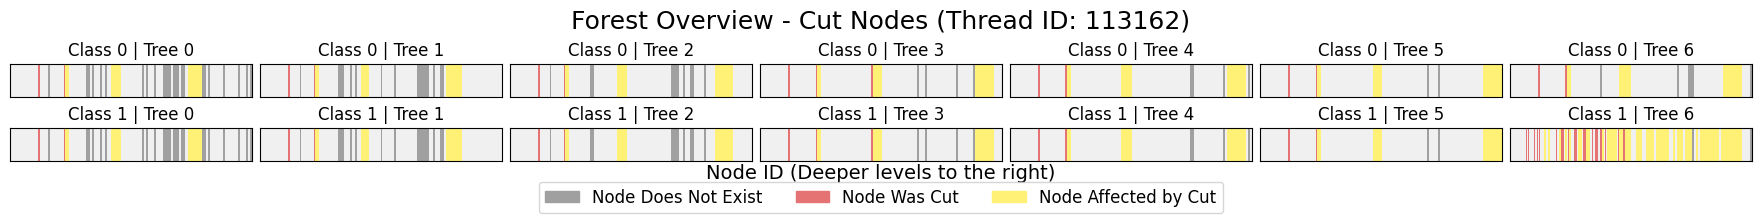

In [131]:

trees_data = xgb2gpu.model.trees
# plot_tree_cut_distribution(trees_data, num_threads=10000, 
#                            num_classes=xgb_params['num_class'], 
#                            num_trees_per_class=xgb_params['n_estimators'])

# --- FUNCTION CALLS ---
# 1. Generate individual images for each tree.
visualize_tree_traversal_path(
    trees=trees_data,
    thread_id_to_plot=thread_to_visualize,
    num_classes=xgb_params['num_class'],
    num_trees_per_class=xgb_params['n_estimators'],
    output_dir=f'./results/{thread_to_visualize}_individual_trees',
    font_size=12
)

# 2. Generate the single image with the forest overview.
cutted = plot_forest_overview(
    trees=trees_data,
    thread_id_to_plot=thread_to_visualize,
    num_classes=xgb_params['num_class'],
    num_trees_per_class=xgb_params['n_estimators'],
    output_file='./results/forest_overview',
    font_size=12)

print(f"Total nodes cut by thread {thread_to_visualize}: {cutted}")


## Rodar cuda

In [132]:
! cd results && \
! nvcc -arch=sm_89 -O3 -lineinfo -o xgboost_cuda_generated xgboost_cuda_generated.cu -O3 -Wno-deprecated-gpu-targets

In [133]:
! cd results && \
! ./xgboost_cuda_generated


Kernel execution time: 4118.93 ms


In [134]:
y_pred_treelut = treelut_clf.predict(X_valid_min_max)
print(f"Acurácia TreeLUT: {accuracy_score(y_pred_treelut, y_valid):.3f}")


Acurácia TreeLUT: 0.875


In [135]:
y_xgb2gpu = xgb2gpu.predict(X = X_test_min_max, thread_id=thread_to_visualize)
print(f"Acurácia XGBoost2GPU: {accuracy_score(y_xgb2gpu, y_test):.3f}")

Acurácia XGBoost2GPU: 0.872


In [136]:
y_xgb2gpu = xgb2gpu.predict(X = X_test_min_max, thread_id=0)
print(f"Acurácia XGBoost2GPU: {accuracy_score(y_xgb2gpu, y_test):.3f}")

Acurácia XGBoost2GPU: 0.877


### Predição com XGBoost2GPU usando classical pruning